# Satellite Sun/Moon Transit Footprint Demo

Compute and plot the projected footprint (approximate ellipse) on Earth where a satellite would transit the Sun or Moon over a time range.

This uses:
- `functions.common.sat_sun_moon_transit.compute_transit_footprint`
- `functions.common.sat_sun_moon_transit.compute_transit_footprints_over_range`

Optional: install plotting deps if needed.


In [6]:
# If running in a fresh environment, uncomment to install requirements
%pip install -q sgp4 astropy matplotlib shapely
%pip install -q cartopy
%pip install -q ipywidgets


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [7]:
import os, sys, math, time
sys.path.insert(0, os.getcwd())  # ensure repo root is importable

from sat_sun_moon_transit import (
    compute_transit_footprints_over_range,
    compute_transit_footprint,
)
import matplotlib.pyplot as plt
# For Sun subsolar point computation
from astropy.time import Time
from astropy.coordinates import ITRS, get_sun
import astropy.units as u


In [8]:
# Parameters
# ISS TLE (example from tests)
line1 = '1 25544U 98067A   25297.71697619  .00017304  00000+0  31673-3 0  9998'
line2 = '2 25544  51.6348  25.1812 0004566 333.5945  26.4810 15.49427280535254'

# Time window (UTC, can include timezone offsets)
start_time = '2025-10-26T16:12:00+00:00'
end_time   = '2025-10-26T16:14:20+00:00'

# Body for transit cone ('sun' or 'moon')
body = 'sun'

# Sampling
step_seconds = 1.0   # time stride between footprints
num_points   = 60    # points along footprint boundary


In [9]:
# Compute footprints
t0 = time.time()
footprints = compute_transit_footprints_over_range(
    line1, line2, start_time, end_time,
    step_seconds=step_seconds, body=body, num_points=num_points,
    return_shapely=False
)
dt = time.time() - t0
len(footprints), f'computed in {dt:.2f}s'


(136, 'computed in 4.01s')

In [10]:
# Compute center-axis projection error between sphere and ellipsoid intersections (km)
from astropy.time import Time
import numpy as np
import os, sys
# Ensure repo root on sys.path regardless of CWD
repo_root = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)
from functions.common.sat_sun_moon_transit import (
    _satellite_gcrs_position, _body_gcrs_position,
    _compute_itrs_linearization, _map_dir_gcrs_to_itrs,
    _ray_wgs84_intersection,
)
from functions.common.geo_utils import (
    ray_sphere_intersection, EARTH_MEAN_RADIUS_M,
)

def _axis_dir_itrs(line1, line2, t_iso, body):
    t = Time(t_iso, format='isot', scale='utc')
    sat_gcrs = _satellite_gcrs_position(line1, line2, t)
    body_gcrs = _body_gcrs_position(body, t)
    sat_xyz_km = np.vstack(sat_gcrs.cartesian.xyz.to_value('km')).ravel()
    body_xyz_km = np.vstack(body_gcrs.cartesian.xyz.to_value('km')).ravel()
    axis = sat_xyz_km - body_xyz_km
    axis_unit = axis / np.linalg.norm(axis)
    origin_ecef, J = _compute_itrs_linearization(sat_gcrs, t)
    to_earth_center = -origin_ecef
    d_fwd = _map_dir_gcrs_to_itrs(axis_unit, J)
    d_back = _map_dir_gcrs_to_itrs(-axis_unit, J)
    use_forward = (np.dot(d_fwd, to_earth_center) > np.dot(d_back, to_earth_center))
    axis_dir = d_fwd if use_forward else d_back
    return origin_ecef, axis_dir

def compute_axis_intersection_error_series(footprints, line1, line2, body):
    times = []
    errors_km = []
    for fp in footprints:
        t_iso = fp.get('time')
        if not t_iso:
            continue
        origin_ecef, axis_dir = _axis_dir_itrs(line1, line2, t_iso, body)
        p_e = _ray_wgs84_intersection(origin_ecef, axis_dir)
        p_s = ray_sphere_intersection(origin_ecef, axis_dir, EARTH_MEAN_RADIUS_M)
        if p_e is None or p_s is None:
            continue
        err_m = float(np.linalg.norm(p_e - p_s))
        times.append(t_iso)
        errors_km.append(err_m / 1000.0)
    return times, errors_km


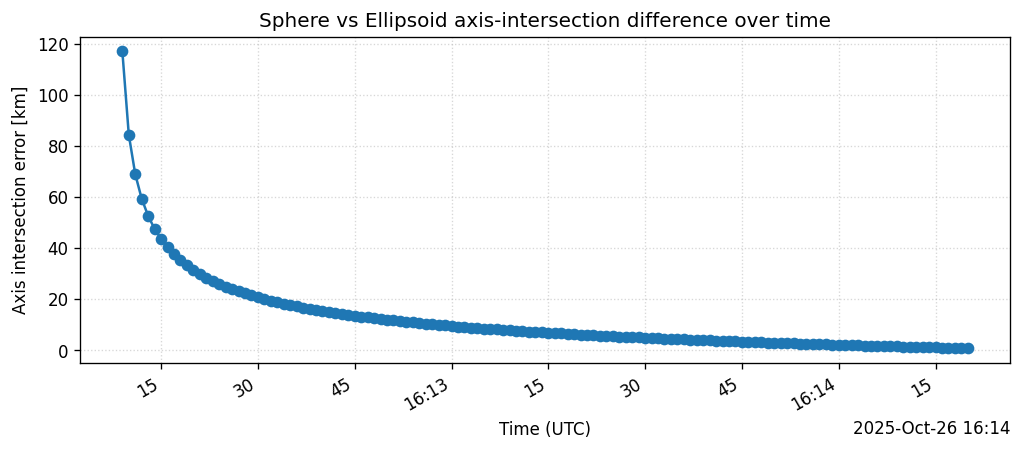

In [11]:
# Plot error (km) vs footprint time
import matplotlib.dates as mdates
from datetime import datetime
times, errs_km = compute_axis_intersection_error_series(footprints, line1, line2, body)
if times:
    # Convert ISO times to datetime objects
    xs = [datetime.fromisoformat(t.replace('Z','+00:00')) for t in times]
    fig, ax = plt.subplots(figsize=(10,4), dpi=120)
    ax.plot(xs, errs_km, marker='o', lw=1.5)
    ax.set_xlabel('Time (UTC)')
    ax.set_ylabel('Axis intersection error [km]')
    ax.set_title('Sphere vs Ellipsoid axis-intersection difference over time')
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(mdates.AutoDateLocator()))
    ax.grid(True, linestyle=':', alpha=0.5)
    fig.autofmt_xdate()
    plt.show()
else:
    print('No intersection error data to plot.')


In [12]:
# Helper to split lines at the dateline to avoid long wraparound segments
def split_wrap(lons, lats):
    if not lons or not lats:
        return []
    segs = []
    cur_lon, cur_lat = [lons[0]], [lats[0]]
    for i in range(1, len(lons)):
        lon0, lon1 = lons[i-1], lons[i]
        lat0, lat1 = lats[i-1], lats[i]
        if abs(lon1 - lon0) > 180:
            # break segment
            segs.append((cur_lon, cur_lat))
            cur_lon, cur_lat = [lon1], [lat1]
        else:
            cur_lon.append(lon1)
            cur_lat.append(lat1)
    if cur_lon:
        segs.append((cur_lon, cur_lat))
    return segs

# Compute Sun subsolar point (lat, lon) at a given ISO time
def subsolar_latlon(isot_time):
    try:
        t = Time(isot_time, format='isot', scale='utc')
    except Exception:
        t = Time(isot_time)
    sun_itrs = get_sun(t).transform_to(ITRS(obstime=t))
    x, y, z = [c.to_value(u.m) for c in sun_itrs.cartesian.xyz]
    r = math.sqrt(x*x + y*y + z*z)
    if r == 0:
        return None, None
    lat = math.degrees(math.asin(z / r))
    lon = math.degrees(math.atan2(y, x))
    return lat, lon


In [13]:
# Plot ONE footprint on an Earth map (uses cartopy if available)
try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    _HAS_CARTOPY = True
except Exception:
    _HAS_CARTOPY = False

def plot_footprint_map(fp, title=None, show_ellipsoid_center=True, show_polygon_dot=True):
    # Note: show_polygon_dot now controls polygon REGION fill instead of a dot.
    if not fp:
        print('No footprint for this time')
        return
    lons = fp.get('lons') or []
    lats = fp.get('lats') or []
    if title is None:
        meta = fp.get('meta') or {}
        body = meta.get('body', 'sun')
        title = f"Transit footprint ({body}) {fp.get('time','')}"
    if _HAS_CARTOPY:
        fig = plt.figure(figsize=(11, 5.5), dpi=120)
        ax = plt.axes(projection=ccrs.PlateCarree())
        ax.set_global()
        ax.coastlines('110m', linewidth=0.8)
        ax.add_feature(cfeature.BORDERS, linewidth=0.3)
        gl = ax.gridlines(draw_labels=True, linewidth=0.2, color='gray', alpha=0.5, linestyle=':')
        gl.right_labels = False; gl.top_labels = False
        # Footprint polygon boundary and optional fill
        labeled=False
        if lons and lats:
            for (slon, slat) in split_wrap(lons, lats):
                if show_polygon_dot and len(slon) >= 3 and len(slat) >= 3:
                    ax.fill(slon, slat, transform=ccrs.PlateCarree(), color='tab:blue', alpha=0.25, label='polygon fill' if not labeled else None)
                    labeled=True
                ax.plot(slon, slat, transform=ccrs.PlateCarree(), color='tab:blue', lw=1.8, alpha=0.8)
        labels = []
        # Ellipsoid center
        if show_ellipsoid_center:
            c = fp.get('center') or {}
            if c.get('lon') is not None and c.get('lat') is not None:
                ax.plot([c['lon']],[c['lat']], marker='x', ms=6, color='tab:green', transform=ccrs.PlateCarree(), label='ellipsoid center')
                labels.append('ellipsoid center')
        # Sun subsolar point as a small orange dot
        try:
            s_lat, s_lon = subsolar_latlon(fp.get('time'))
        except Exception:
            s_lat, s_lon = (None, None)
        if s_lon is not None and s_lat is not None:
            ax.plot([s_lon],[s_lat], marker='o', ms=3, color='orange', transform=ccrs.PlateCarree(), label='subsolar point')
            labels.append('subsolar point')
        # Sub-satellite point (ground track position)
        ss = fp.get('subsat') or {}
        if ss.get('lon') is not None and ss.get('lat') is not None:
            ax.plot([ss['lon']],[ss['lat']], marker='*', ms=7, color='k', transform=ccrs.PlateCarree(), label='subsat point')
            labels.append('subsat point')
        ax.set_title(title)
        if labeled or labels:
            ax.legend(loc='lower left')
        plt.show()
    else:
        fig, ax = plt.subplots(figsize=(11, 5.5), dpi=120)
        ax.set_title(title)
        ax.set_xlabel('Longitude [deg]')
        ax.set_ylabel('Latitude [deg]')
        ax.set_xlim(-180, 180)
        ax.set_ylim(-90, 90)
        ax.grid(True, linestyle=':', alpha=0.5)
        labeled=False
        if lons and lats:
            for (slon, slat) in split_wrap(lons, lats):
                if show_polygon_dot and len(slon) >= 3 and len(slat) >= 3:
                    ax.fill(slon, slat, color='tab:blue', alpha=0.25, label='polygon fill' if not labeled else None)
                    labeled=True
                ax.plot(slon, slat, color='tab:blue', lw=1.8, alpha=0.8)
        if show_ellipsoid_center:
            c = fp.get('center') or {}
            if c.get('lon') is not None and c.get('lat') is not None:
                ax.plot([c['lon']],[c['lat']], marker='x', ms=6, color='tab:green', label='ellipsoid center')
                labeled=True
        # Sun subsolar point as a small orange dot
        try:
            s_lat, s_lon = subsolar_latlon(fp.get('time'))
        except Exception:
            s_lat, s_lon = (None, None)
        if s_lon is not None and s_lat is not None:
            ax.plot([s_lon],[s_lat], marker='o', ms=3, color='orange', label='subsolar point')
            labeled=True
        # Sub-satellite point (ground track position)
        ss = fp.get('subsat') or {}
        if ss.get('lon') is not None and ss.get('lat') is not None:
            ax.plot([ss['lon']],[ss['lat']], marker='*', ms=7, color='k', label='subsat point')
            labeled=True
        if labeled:
            ax.legend(loc='lower left')
        plt.show()


In [ ]:
# Interactive slider to select and plot a single footprint
import ipywidgets as widgets
from IPython.display import display

def _plot_one(i, show_ellipsoid_center=True, show_polygon_dot=True):
    if not (isinstance(footprints, list) and len(footprints) > 0):
        print('No footprints to plot; compute them first.')
        return
    i = max(0, min(i, len(footprints)-1))
    plot_footprint_map(footprints[i], show_ellipsoid_center=show_ellipsoid_center, show_polygon_dot=show_polygon_dot)

if 'footprints' in globals() and isinstance(footprints, list) and len(footprints) > 0:
    idx_slider = widgets.IntSlider(min=0, max=len(footprints)-1, step=1, value=0, description='Index')
    show_ellipsoid_cb = widgets.Checkbox(value=True, description='Ellipsoid center')
    show_poly_cb = widgets.Checkbox(value=True, description='Polygon fill')
    controls = widgets.HBox([idx_slider, show_ellipsoid_cb, show_poly_cb])
    out = widgets.interactive_output(_plot_one, {
        'i': idx_slider,
        'show_ellipsoid_center': show_ellipsoid_cb,
        'show_polygon_dot': show_poly_cb
    })
    display(controls, out)
else:
    print('Compute footprints first, then rerun this cell to enable the slider.')


Output()

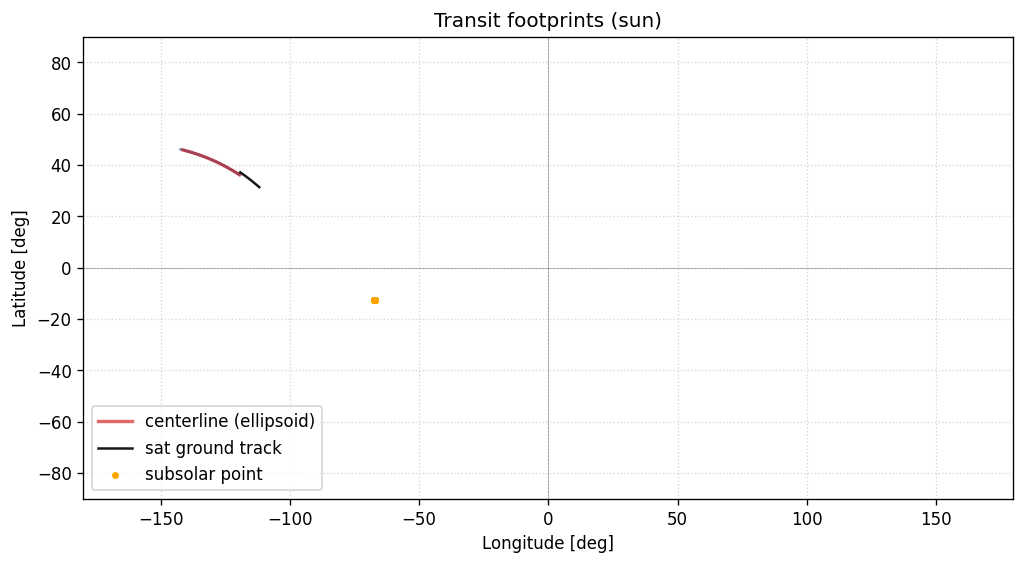

In [15]:
# Plot footprints, center tracks, and satellite ground track
fig, ax = plt.subplots(figsize=(10, 5), dpi=120)
ax.set_title(f'Transit footprints ({body})')
ax.set_xlabel('Longitude [deg]')
ax.set_ylabel('Latitude [deg]')
ax.set_xlim(-180, 180)
ax.set_ylim(-90, 90)
ax.grid(True, linestyle=':', alpha=0.5)

ax.axhline(0, color='k', lw=0.5, alpha=0.3)
ax.axvline(0, color='k', lw=0.5, alpha=0.3)

centers_lon, centers_lat = [], []
trk_lon, trk_lat = [], []
sun_lon, sun_lat = [], []
for i, fp in enumerate(footprints):
    lons = fp['lons']
    lats = fp['lats']
    if lons and lats:
        segs = split_wrap(lons, lats)
        for (slon, slat) in segs:
            ax.plot(slon, slat, color='tab:blue', alpha=0.25, lw=1)
    c = fp.get('center') or {}
    if c.get('lon') is not None and c.get('lat') is not None:
        centers_lon.append(c['lon'])
        centers_lat.append(c['lat'])
    # Sun subsolar point for this timestamp
    try:
        s_lat, s_lon = subsolar_latlon(fp.get('time'))
    except Exception:
        s_lat, s_lon = (None, None)
    if s_lon is not None and s_lat is not None:
        sun_lon.append(s_lon)
        sun_lat.append(s_lat)
    ss = fp.get('subsat') or {}
    if ss.get('lon') is not None and ss.get('lat') is not None:
        trk_lon.append(ss['lon'])
        trk_lat.append(ss['lat'])

# Plot centerline (ellipsoid)
if centers_lon and centers_lat:
    segs = split_wrap(centers_lon, centers_lat)
    first=True
    for (slon, slat) in segs:
        ax.plot(slon, slat, color='tab:red', lw=2, alpha=0.7, label='centerline (ellipsoid)' if first else None)
        first=False

# Plot satellite ground track (sub-satellite)
if trk_lon and trk_lat:
    segs = split_wrap(trk_lon, trk_lat)
    first=True
    for (slon, slat) in segs:
        ax.plot(slon, slat, color='k', lw=1.5, alpha=0.9, linestyle='-', label='sat ground track' if first else None)
        first=False

# Plot Sun subsolar points (small orange dots)
if sun_lon and sun_lat:
    ax.scatter(sun_lon, sun_lat, s=10, c='orange', label='subsolar point', zorder=5)

ax.legend(loc='lower left')
plt.show()
